# visualizing annos from dissociated data in hexagon

In [ ]:
from pathlib import Path
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np  
import polars as pl
from scipy import sparse

import matplotlib.pyplot as plt

In [2]:
base_path = Path("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb")
#global_analysis_out = Path("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb/kackhaufen1/global_motif_analysis.rds")
path_spatial = base_path / "adata.h5ad"
multiome_path = base_path / "healthy_breast_preprocessed_RNA_peaks_only_with_cell_types.h5ad"
map_tg = base_path / "kackhaufen1/adata_map.h5ad"

In [41]:
spatial_adata = sc.read_h5ad(path_spatial)
spatial_adata.obs.shape

(1275, 57)

In [6]:
spatial_adata.obs.head()

,in_tissue,array_row,array_col,pathologist_annotation,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,...,qc_detected,qc_mito_prop,global_outliers,log1p_total_counts_z,log1p_total_counts_outliers,log1p_n_genes_by_counts_z,log1p_n_genes_by_counts_outliers,pct_counts_mt_z,pct_counts_mt_outliers,local_outliers
AAACCGGGTAGGTACC-1,1,42,28,Adipose tissue,0.076998,0.645444,6.846899e-13,0.102796,1.273444e-01,3.394147e-12,...,False,False,False,0.499680,False,0.607751,False,-0.132932,False,False
AAACCGTTCGTCCAGG-1,1,52,42,Fibrosis,0.429974,0.283151,4.763192e-13,0.089270,3.890135e-02,1.273346e-01,...,False,False,False,0.754912,False,0.836521,False,-6.821667,False,False
AAACCTCATGAAGTTG-1,1,37,19,<NA>,0.234456,0.623560,1.294380e-12,0.051878,7.889010e-03,2.638741e-02,...,False,False,False,0.226059,False,0.164638,False,-1.276950,False,False
AAACGAGACGGTTGAT-1,1,35,79,Fibrosis,0.398729,0.204462,5.587884e-13,0.037272,1.759830e-12,3.374678e-01,...,False,False,False,1.024507,False,0.984986,False,-0.009293,False,False
AAACTGCTGGCTCCAA-1,1,45,67,Fibrosis,0.317247,0.117703,8.046805e-13,0.074632,2.241093e-02,4.278375e-01,...,False,False,False,0.023397,False,-0.208662,False,-1.003031,False,False


In [42]:
multiome_adata = sc.read_h5ad(multiome_path)
multiome_adata.obs.shape

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


(5220, 23)

In [14]:
multiome_adata.obs.head() # eg cell type 

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC,percent.mt,nucleosome_signal,nucleosome_percentile,TSS.enrichment,TSS.percentile,...,nFeature_SCT,RNA.weight,peaks.weight,RNA_peaks_clusters_res0.2,RNA_peaks_clusters_res0.1,RNA_peaks_clusters_res0.05,SCT.weight,SCT_peaks_clusters_res0.2,SCT_peaks_clusters_res0.1,cell_type
AAACAGCCAAACTAAG-1,0,5984.0,3067,822.0,445,0.100267,0.969231,0.16,4.865723,0.87,...,1264,0.317982,0.247865,1,1,1,0.752135,1,1,1
AAACAGCCAAAGCTAA-1,0,2622.0,1407,2315.0,1194,0.000000,0.866029,0.10,4.199134,0.64,...,1405,0.425636,0.975121,3,3,3,0.024879,3,3,3
AAACAGCCACCTAATG-1,0,7845.0,3169,9264.0,4768,0.025494,1.607815,0.90,3.636191,0.30,...,1263,0.678550,0.245549,4,4,5,0.754451,4,4,4
AAACATGCAAACATAG-1,0,525.0,461,975.0,527,0.000000,1.125000,0.31,4.317422,0.70,...,488,0.395767,0.837649,0,0,0,0.162351,0,0,0
AAACATGCACAAGCCT-1,0,1422.0,999,15954.0,7333,0.281294,1.144059,0.33,4.218566,0.65,...,999,0.558170,0.298276,0,0,0,0.701724,0,0,0


In [15]:
map_tg_adata = sc.read_h5ad(map_tg)

In [ ]:
map_tg_adata.obs["cell_type"] 

AAACAGCCAAACTAAG-1    1
AAACAGCCAAAGCTAA-1    3
AAACAGCCACCTAATG-1    4
AAACATGCAAACATAG-1    0
AAACATGCACAAGCCT-1    0
                     ..
TTTGTGTTCTATGACA-1    1
TTTGTGTTCTGTGAGT-1    6
TTTGTTGGTAACGGGA-1    5
TTTGTTGGTGAAACAA-1    1
TTTGTTGGTGATGAAA-1    4
Name: cell_type, Length: 5220, dtype: category
Categories (10, int32): [0, 1, 2, 3, ..., 6, 7, 8, 9]

In [40]:
def map_dissociated_annos_to_spatial(map_tg_adata, obs_anno_col="cell_type"):
        
    X = map_tg_adata.X
    cell_type = map_tg_adata.obs[obs_anno_col]

    # keep category order exactly as stored
    cats = cell_type.cat.categories

    # one-hot encode cell types: shape (n_cells, n_types)
    onehot = pd.get_dummies(cell_type).reindex(columns=cats, fill_value=0)

    # convert to array/sparse matrix
    if sparse.issparse(X):
        spot_type_sum = onehot.to_numpy().T @ X   # shape: (n_types, n_spots)
        spot_type_sum = spot_type_sum.toarray() if sparse.issparse(spot_type_sum) else np.asarray(spot_type_sum)
    else:
        spot_type_sum = onehot.to_numpy().T @ np.asarray(X)  # shape: (n_types, n_spots)

    # make DataFrame: rows = spots, cols = cell types
    spot_type_sum_df = pd.DataFrame(
        spot_type_sum.T,
        index=map_tg_adata.var_names,   # spots
        columns=cats                    # cell type categories
    )

    spot_type_prob_df = spot_type_sum_df.div(spot_type_sum_df.sum(axis=1), axis=0).fillna(0)
    map_tg_adata.varm[f"{obs_anno_col}_dissociated_sum"] = spot_type_sum_df.to_numpy()
    map_tg_adata.varm[f"{obs_anno_col}_dissociated_prob"] = spot_type_prob_df.to_numpy()
    map_tg_adata.uns[f"{obs_anno_col}_dissociated_columns"] = list(cats)


    cell_type_prob = map_tg_adata.varm[f"{obs_anno_col}_dissociated_prob"]
    cell_type_names = np.array(map_tg_adata.uns[f"{obs_anno_col}_dissociated_columns"])

    max_idx = np.argmax(cell_type_prob, axis=1)
    map_tg_adata.var[f"{obs_anno_col}_dissociated_max_prob"] = cell_type_names[max_idx]


    return map_tg_adata

In [73]:
map_tg_adata = map_dissociated_annos_to_spatial(map_tg_adata, obs_anno_col="cell_type")

### heart data

In [81]:
base_path = Path("/nfs/home/students/m.back/swarm/backend/uploads/job_1773738454743_mopitas/")
#global_analysis_out = Path("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb/kackhaufen1/global_motif_analysis.rds")
path_spatial = base_path / "visium-OCT_AVN_norm_log1pA61_light.fixed.h5ad"
multiome_path = base_path / "HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.h5ad"
map_tg = base_path / "junkDNA420/adata_map.h5ad"

In [ ]:
heart_spatial_adata = sc.read_h5ad(path_spatial)

In [44]:
map_tg_adata_heart = sc.read_h5ad(map_tg)

In [49]:
map_tg_adata_heart.obs["cell_type"]

AGGTATTGTCTTTGAC-1    Ventricular Cardiomyocyte
ACTTACTTCATTAGTG-1    Ventricular Cardiomyocyte
CCTTCAATCAGCATTA-1    Ventricular Cardiomyocyte
ATGTTGTCAATACTGT-1    Ventricular Cardiomyocyte
CTTCAATTCATTTGTC-1    Ventricular Cardiomyocyte
                                ...            
CTTTCTTGTAGCTGGT-1                    Adipocyte
AGTTATGTCTCAATGA-1             Endothelial cell
TAGTGTGGTTAGGCGT-1    Ventricular Cardiomyocyte
TGGACTAGTTGTTCAC-1                  Neural cell
CGAACAAAGGAAGCAC-1             Endothelial cell
Name: cell_type, Length: 8358, dtype: category
Categories (11, object): ['Adipocyte', 'Atrial Cardiomyocyte', 'Endothelial cell', 'Fibroblast', ..., 'Mural cell', 'Myeloid', 'Neural cell', 'Ventricular Cardiomyocyte']

In [50]:
map_tg_adata_heart_mapped = map_dissociated_annos_to_spatial(map_tg_adata_heart)

In [55]:
map_tg_adata_heart_mapped

AnnData object with n_obs × n_vars = 8358 × 10278
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sangerID', 'combinedID', 'donor', 'donor_type', 'region', 'region_finest', 'age', 'gender', 'facility', 'cell_or_nuclei', 'modality', 'kit_10x', 'flushed', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'scrublet_score', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'batch_key', 'leiden_scVI', 'cell_type', 'cell_state_HCAv1', 'cell_state_scNym', 'cell_state_scNym_confidence', 'cell_state', 'latent_RT_efficiency', 'latent_cell_probability', 'latent_scale', 'n_counts', '_scvi_batch', '_scvi_labels', 'clus20', 'doublet_cls', 'original_or_new', 'batch', 'scANVI_predictions', 'leiden_scArches', 'peak_sangerID', 'peak_combinedID', 'peak_donor', 'peak_donor_type', 'peak_region', 'peak_region_finest', 'peak_age', 'peak_gender', 'peak_facility', 'peak_cell_or_nuclei', 'peak_modality'

In [58]:
map_tg_adata_heart_mapped.var["cell_type_dissociated_max_prob"].value_counts()

cell_type_dissociated_max_prob
Ventricular Cardiomyocyte    9289
Fibroblast                    973
Endothelial cell               11
Mural cell                      5
Name: count, dtype: int64

In [52]:
map_tg_adata_heart_mapped.varm["cell_type_dissociated_prob"]

array([[6.91448688e-04, 1.27294716e-05, 8.60699713e-02, ...,
        4.17700894e-02, 7.08429934e-03, 6.68793917e-01],
       [7.64601355e-05, 1.29370892e-04, 1.07502677e-01, ...,
        3.31028998e-02, 5.67989657e-03, 6.54996693e-01],
       [4.54118068e-04, 2.53841608e-05, 1.36496216e-01, ...,
        2.28491146e-02, 9.64837708e-03, 3.74798596e-01],
       ...,
       [2.14299089e-05, 1.80613806e-05, 1.04511753e-01, ...,
        4.95819710e-02, 1.52392965e-02, 5.22212982e-01],
       [9.88002466e-06, 7.07770465e-03, 6.21148683e-02, ...,
        1.08847320e-02, 3.37722083e-03, 7.23066688e-01],
       [5.79484215e-04, 3.10399300e-05, 1.70017369e-02, ...,
        1.03312880e-02, 8.73821229e-03, 5.46070039e-01]],
      shape=(10278, 11), dtype=float32)

In [69]:
def plot_cell_type_probs_on_spatial(map_tg_adata, obs_anno_col="cell_type"):

    # cell-type probabilities: shape (n_spots, n_cell_types)
    prob = map_tg_adata.varm[f"{obs_anno_col}_dissociated_prob"]
    cell_types = list(map_tg_adata.uns[f"{obs_anno_col}_dissociated_columns"])

    # ---- choose spot coordinates ----
    # adapt this depending on where your spatial coordinates are stored
    if {"x", "y"}.issubset(map_tg_adata.var.columns):
        coords = map_tg_adata.var[["x", "y"]].to_numpy()
    elif {"array_col", "array_row"}.issubset(map_tg_adata.var.columns):
        coords = map_tg_adata.var[["array_col", "array_row"]].to_numpy()
    else:
        raise ValueError(
            "Could not find spatial coordinates in map_tg_adata.var. "
            "Expected columns like ['x','y'] or ['array_col','array_row']."
        )

    x = coords[:, 0]
    y = coords[:, 1]

    # ---- plot one panel per cell type ----
    n_ct = prob.shape[1]
    ncols = 4
    nrows = int(np.ceil(n_ct / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.ravel(axes)

    for i, ct in enumerate(cell_types):
        ax = axes[i]
        sc = ax.scatter(
            x, y,
            c=prob[:, i],
            s=20,
            cmap="viridis"
        )
        ax.set_title(f"{obs_anno_col} {ct}")
        ax.set_aspect("equal")
        ax.invert_yaxis()   # usually useful for spatial data
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [70]:
def plot_cell_type_probs_on_spatial_shared_axis(map_tg_adata, obs_anno_col="cell_type"):

    prob = map_tg_adata.varm[f"{obs_anno_col}_dissociated_prob"]
    cell_types = list(map_tg_adata.uns[f"{obs_anno_col}_dissociated_columns"])

    if {"x", "y"}.issubset(map_tg_adata.var.columns):
        x = map_tg_adata.var["x"].to_numpy()
        y = map_tg_adata.var["y"].to_numpy()
    elif {"array_col", "array_row"}.issubset(map_tg_adata.var.columns):
        x = map_tg_adata.var["array_col"].to_numpy()
        y = map_tg_adata.var["array_row"].to_numpy()
    else:
        raise ValueError("Need spot coordinates in map_tg_adata.var")

    vmin = 0
    vmax = prob.max()

    n_ct = len(cell_types)
    ncols = 4
    nrows = int(np.ceil(n_ct / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.ravel(axes)

    for i, ct in enumerate(cell_types):
        ax = axes[i]
        sc = ax.scatter(
            x, y,
            c=prob[:, i],
            s=20,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(str(ct))
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    cbar = fig.colorbar(sc, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label("cell-type probability")

    plt.tight_layout()
    plt.show()

In [71]:
def plot_cell_type_probs_on_spatial_histograms(map_tg_adata, obs_anno_col="cell_type"):

    prob = map_tg_adata.varm[f"{obs_anno_col}_dissociated_prob"]
    cell_types = list(map_tg_adata.uns[f"{obs_anno_col}_dissociated_columns"])

    n_ct = len(cell_types)
    ncols = 4
    nrows = int(np.ceil(n_ct / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.ravel(axes)

    for i, ct in enumerate(cell_types):
        ax = axes[i]
        ax.hist(prob[:, i], bins=50)
        ax.set_title(str(ct))
        ax.set_xlabel("probability")
        ax.set_ylabel("n spots")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

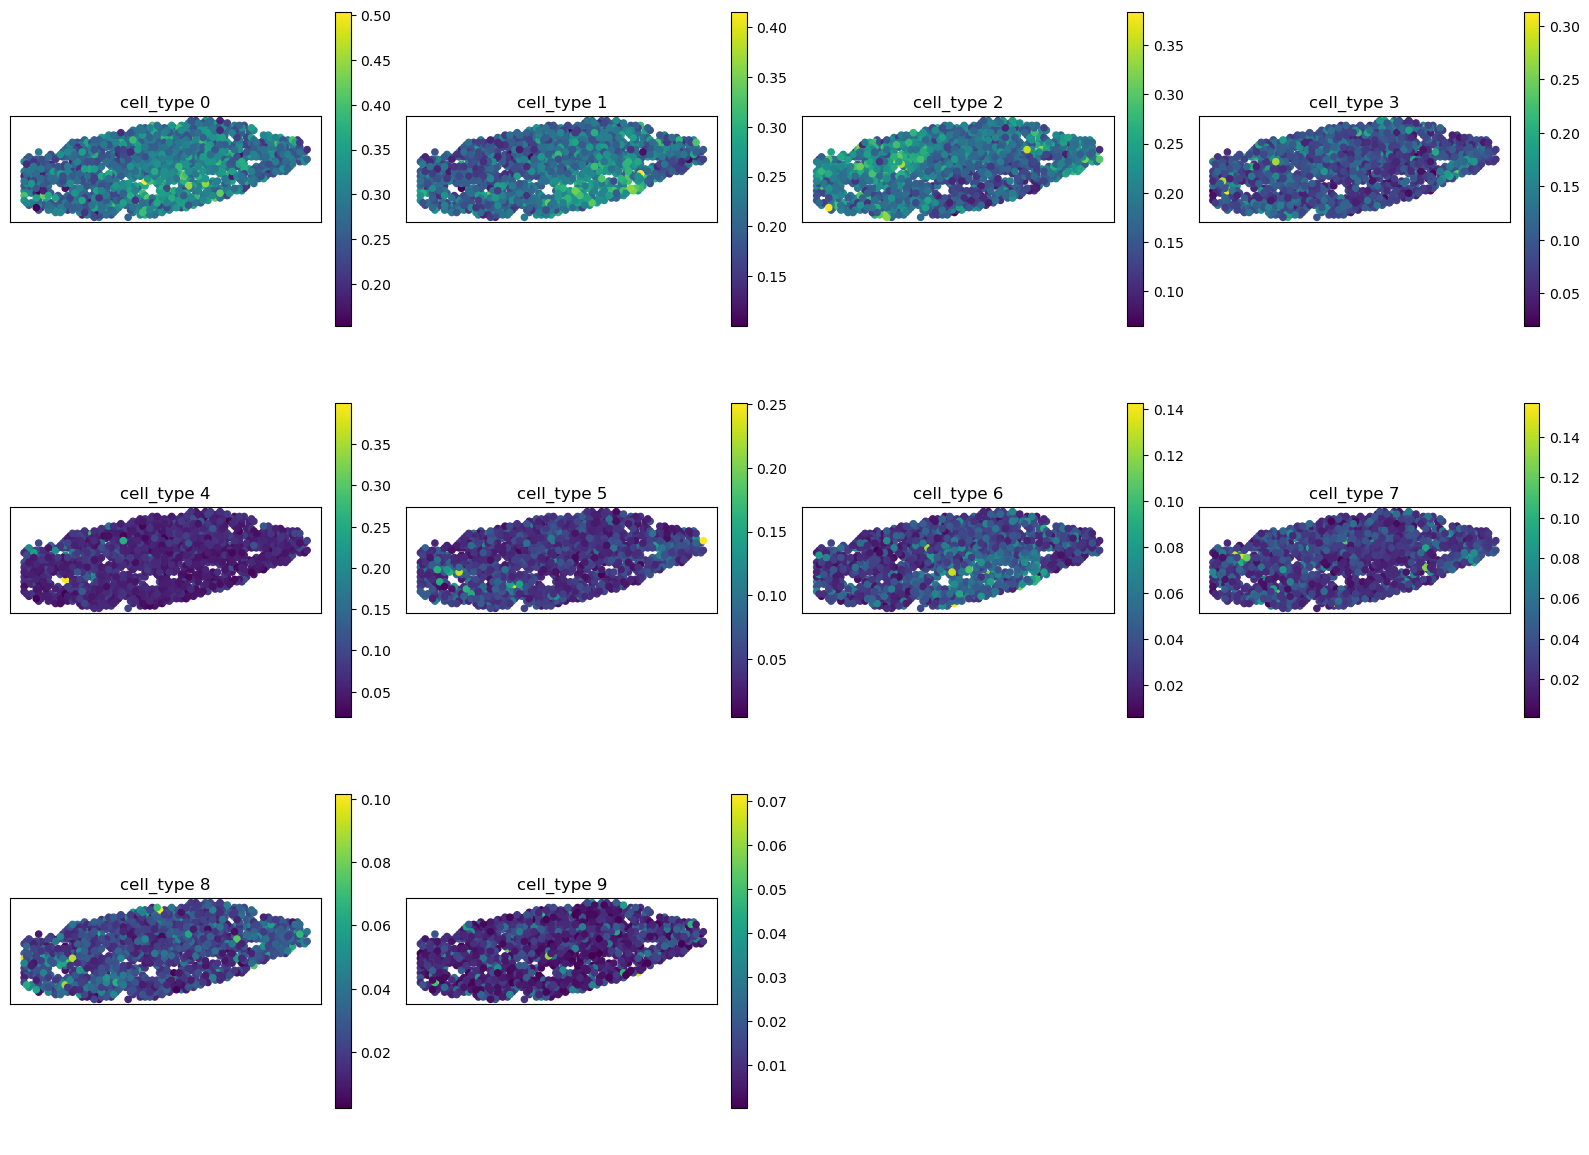

In [74]:
plot_cell_type_probs_on_spatial(map_tg_adata)

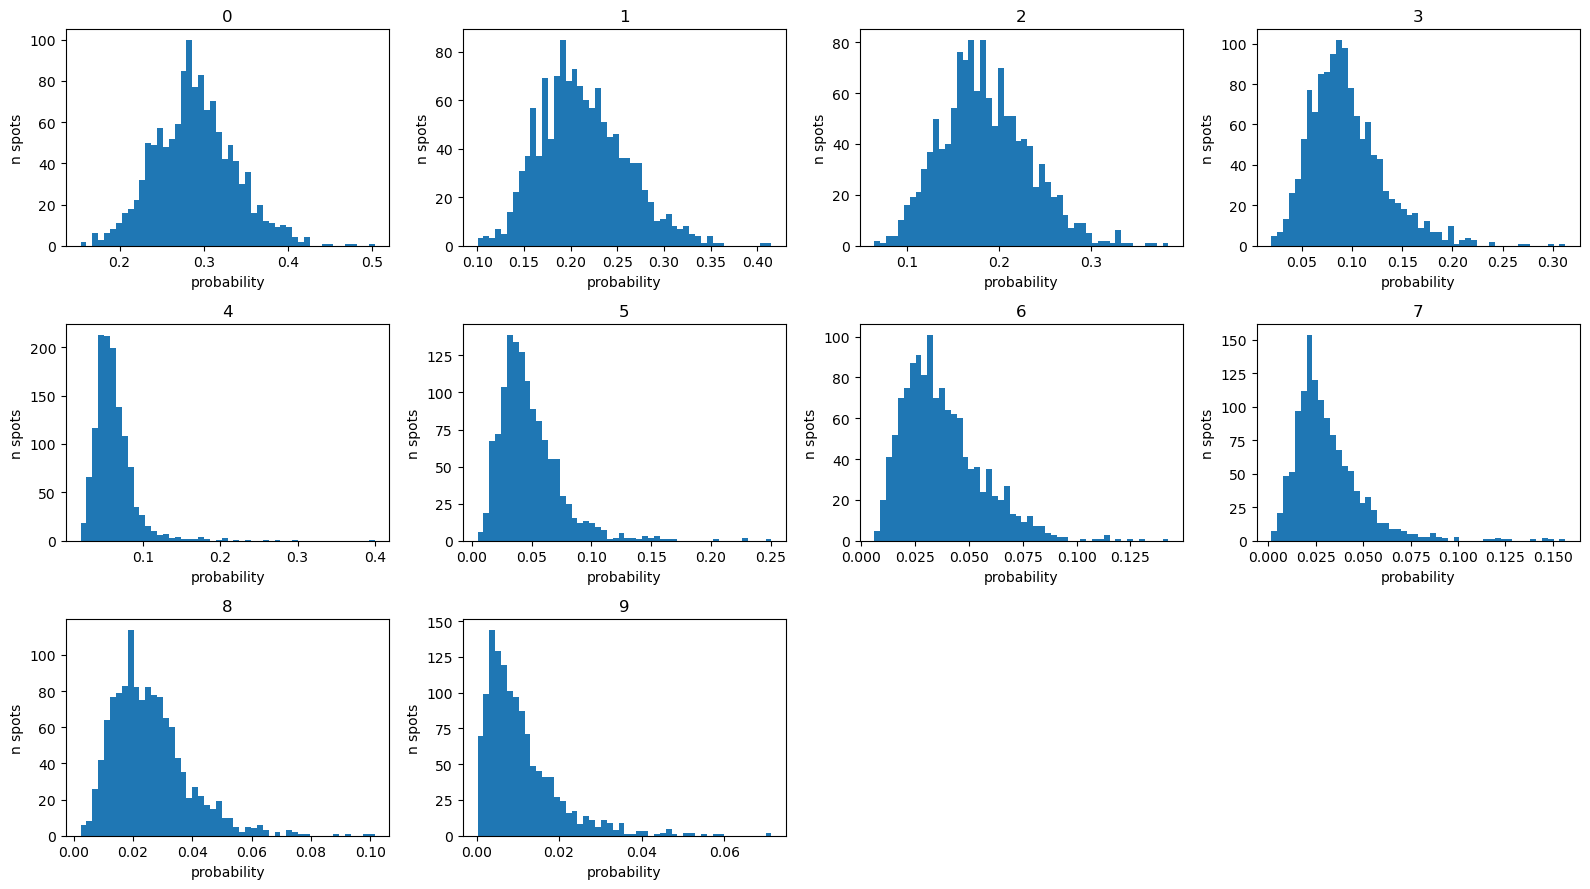

In [75]:
plot_cell_type_probs_on_spatial_histograms(map_tg_adata)

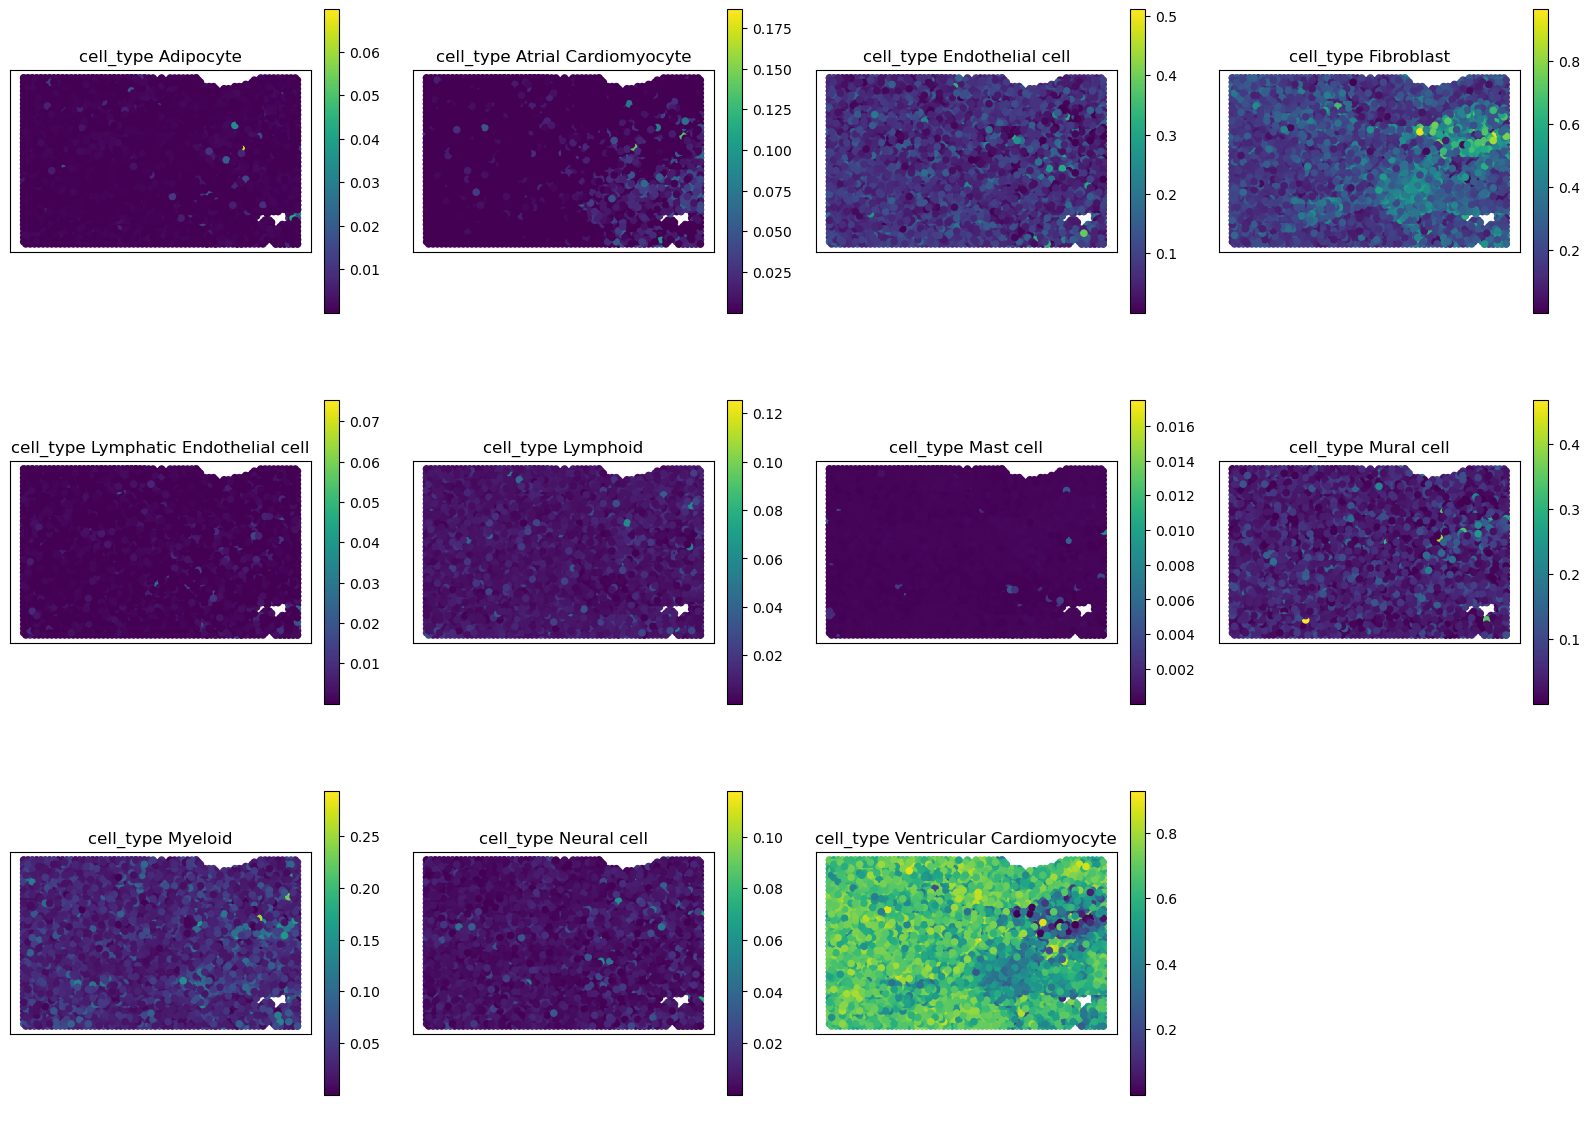

In [77]:
plot_cell_type_probs_on_spatial(map_tg_adata_heart_mapped)

/tmp/ipykernel_1464386/266715154.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


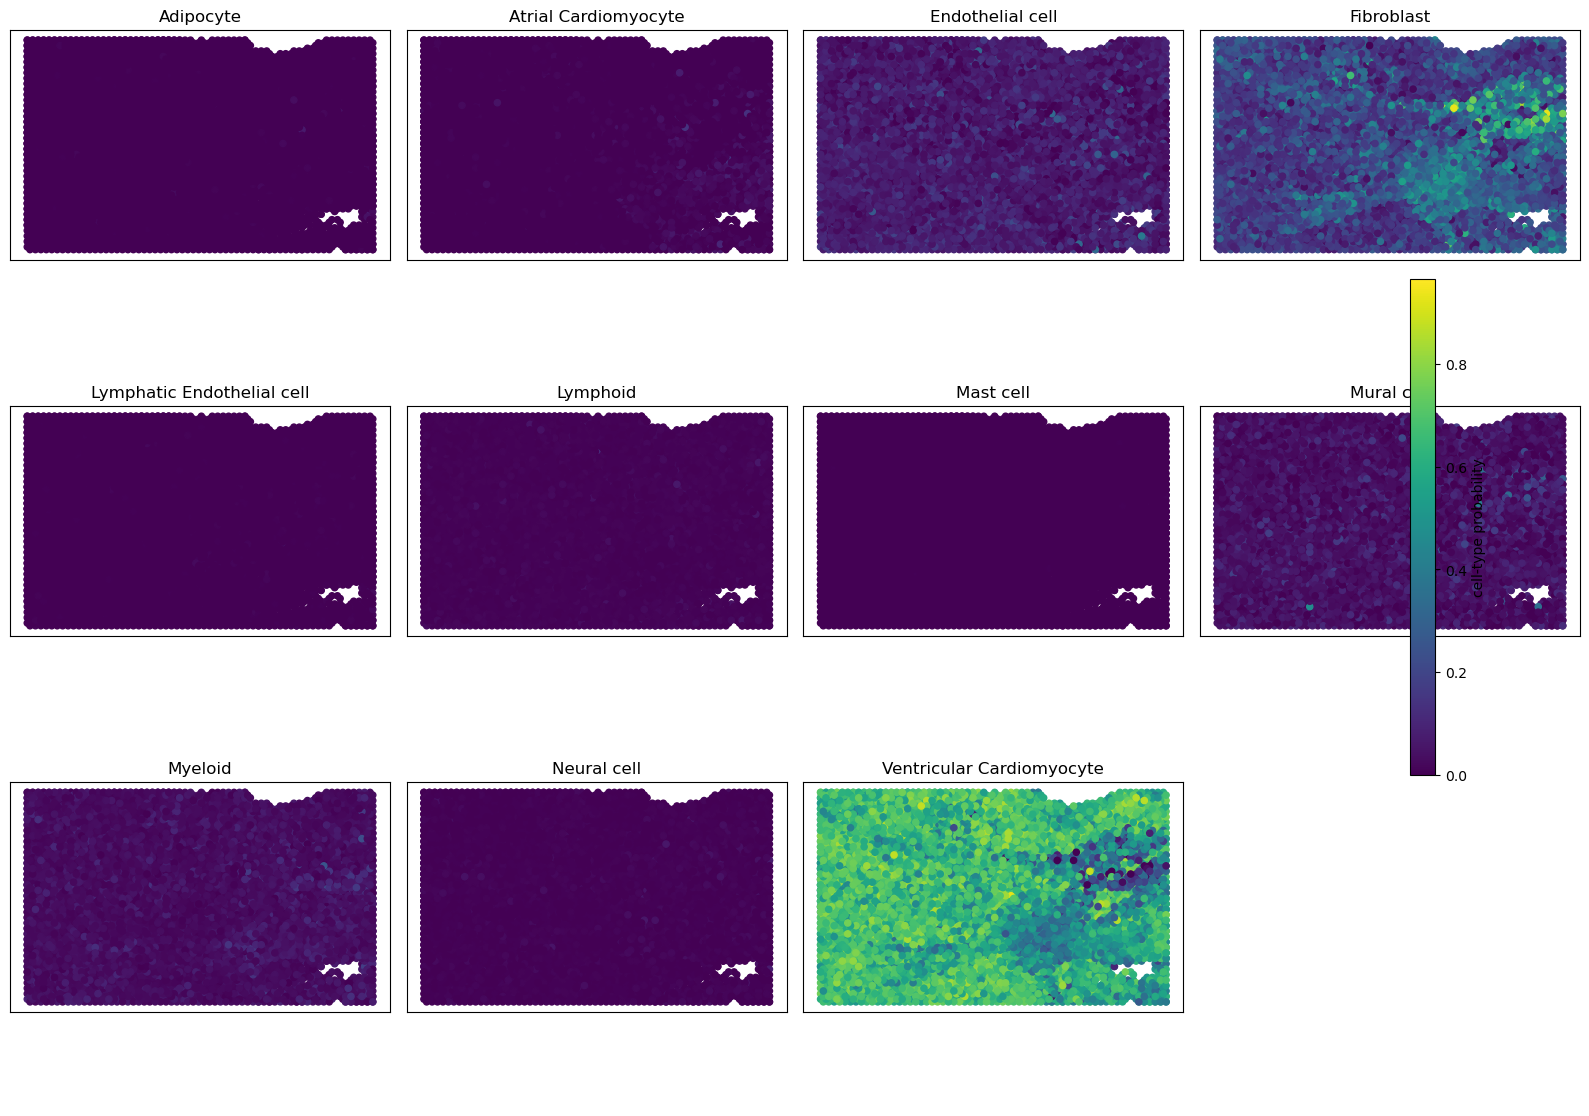

In [79]:
plot_cell_type_probs_on_spatial_shared_axis(map_tg_adata_heart_mapped, obs_anno_col="cell_type")

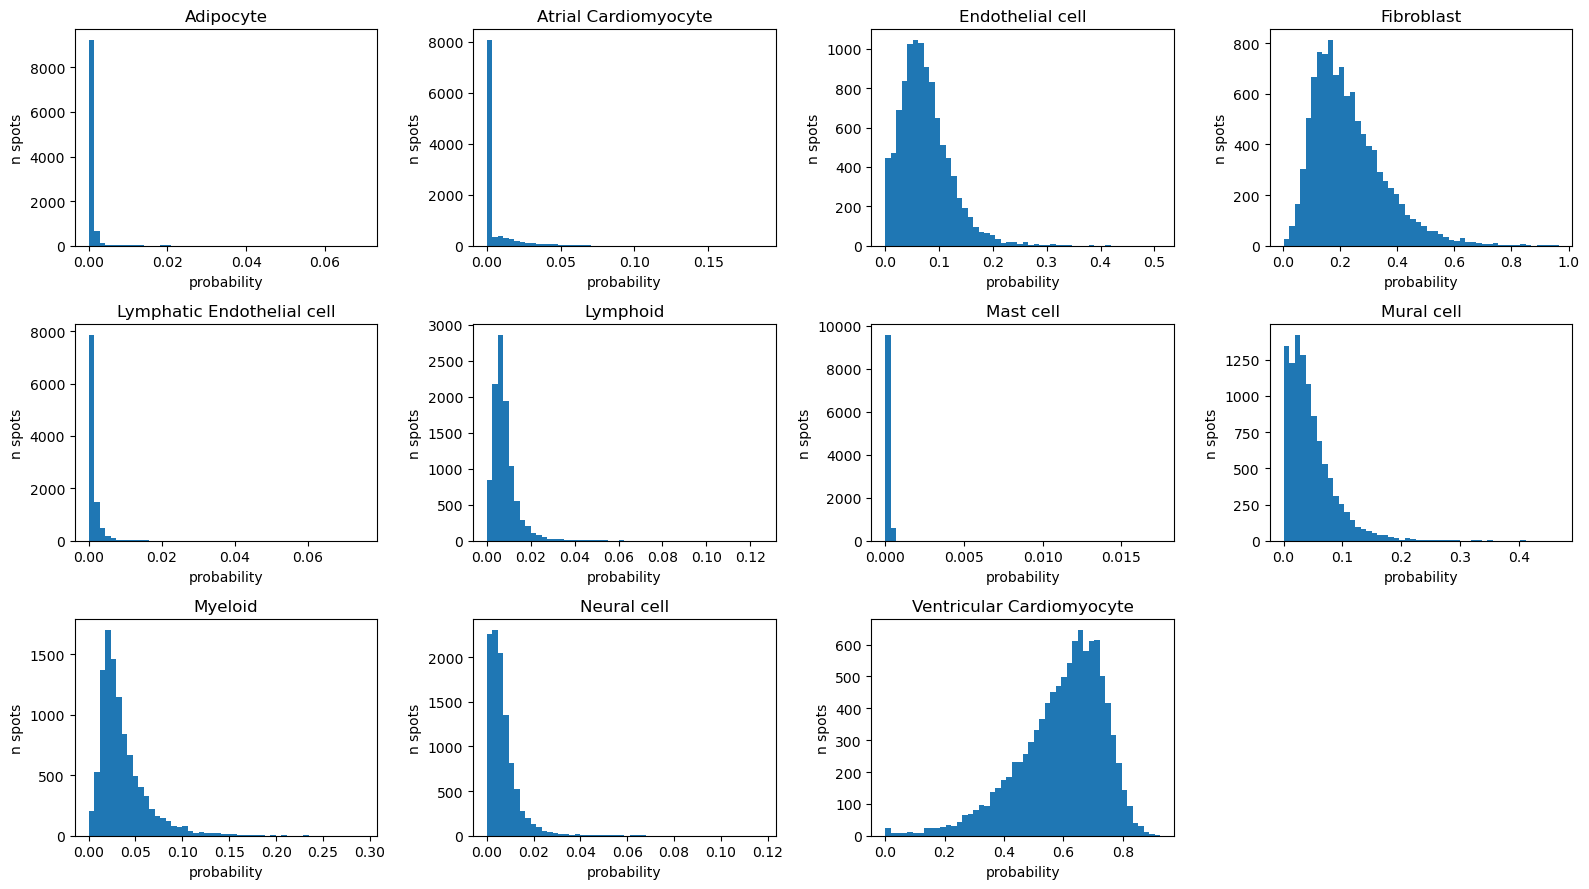

In [76]:
plot_cell_type_probs_on_spatial_histograms(map_tg_adata_heart_mapped)

### todo: 
- test tg with the combination of gene sets that worked best
- only take one slice from spatial: one of 4!!

In [87]:
heart_spatial_adata.obsm["spatial"]

array([[ 3694,  1483],
       [ 6747,  2087],
       [12510,  4279],
       ...,
       [ 5062, 13324],
       [ 4735, 10371],
       [ 7479,  2906]], shape=(10278, 2))

In [91]:
heart_spatial_adata.uns["spatial"].keys()

dict_keys(['HCAHeartST11290657', 'HCAHeartST11290658', 'HCAHeartST11290659', 'HCAHeartST11290662'])

In [93]:
heart_spatial_adata.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,vCM1,vCM2,vCM3_stressed,vCM4,vCM5,broad_celltype,broad_celltype_score,cell_type,broad_celltype_top2,broad_celltype_margin
spot_id,,,,,,,,,,,,,,,,,,,,,
HCAHeartST11290657_AAACAACGAATAGTTC-1,1,0,16,HCAHeartST11290657,1227,7.113142,3086.0,8.034955,45.268957,52.786779,...,0.059522,0.023024,0.030238,8.035143,0.506844,Ventricular_Cardiomyocyte,8.654772,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,6.857023
HCAHeartST11290657_AAACAATCTACTAGCA-1,1,3,43,HCAHeartST11290657,571,6.349139,1073.0,6.979145,44.641193,54.426841,...,0.027643,0.012653,0.021668,3.204051,0.080626,Ventricular_Cardiomyocyte,3.346641,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,2.807692
HCAHeartST11290657_AAACAGAGCGACTCCT-1,1,14,94,HCAHeartST11290657,642,6.466145,1134.0,7.034388,38.624339,47.795414,...,0.042561,0.020730,0.073389,1.347330,0.034062,Ventricular_Cardiomyocyte,1.518072,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Fibroblast,0.494889
HCAHeartST11290657_AAACCGGAAATGTTAA-1,1,54,124,HCAHeartST11290657,546,6.304449,1196.0,7.087574,51.421405,60.200669,...,0.015643,0.008062,0.023945,0.547026,0.014180,Endothelial,0.763192,Endothelial,Endothelial|Atrial_Cardiomyocyte,0.019707
HCAHeartST11290657_AAACCGGGTAGGTACC-1,1,42,28,HCAHeartST11290657,495,6.206576,808.0,6.695799,37.747525,50.123762,...,0.024863,0.017944,0.023745,0.977834,0.038686,Ventricular_Cardiomyocyte,1.083072,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Fibroblast,0.337797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HCAHeartST11290662_TTGTTCTAGATACGCT-1,1,21,3,HCAHeartST11290662,1053,6.960348,2537.0,7.839132,47.694127,54.434371,...,0.092786,0.012702,0.057502,3.534697,0.161541,Ventricular_Cardiomyocyte,3.859228,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,3.237142
HCAHeartST11290662_TTGTTTCACATCCAGG-1,1,58,42,HCAHeartST11290662,1286,7.160069,2530.0,7.836370,31.027668,39.328063,...,0.065781,0.018153,0.124392,1.526806,0.035284,Fibroblast,2.004893,Fibroblast,Fibroblast|Ventricular_Cardiomyocyte,0.234477
HCAHeartST11290662_TTGTTTCATTAGTCTA-1,1,60,30,HCAHeartST11290662,835,6.728629,1861.0,7.529407,46.265449,54.218162,...,0.051487,0.011019,0.081784,4.037649,0.049657,Ventricular_Cardiomyocyte,4.231595,Ventricular_Cardiomyocyte,Ventricular_Cardiomyocyte|Endothelial,3.696453
